# Knowing about executions on the tree

## Introduction

This notebook shall provide a tutorial on how to define your own execution functions and model to execute them. To do this, we shall use a concrete example: **estimation of inner nodes**, which is a classical problem is the field of phylogenetic comparative methods, that is, **given the topology of a phylogenetic tree and observations at its leaf nodes, how to estimate the rest of nodes in this tree?** 

To begin with, we shall use a simple estimation model: **any non-leaf node can be estimated as the weighted mean of its children**, i.e.
$$
\hat{x} = \sum^k_{i=1} \frac{1}{w_i} x^{\text{ch}(x)}_i,
$$
where $\hat{x}$ is the estimation of current node, and $x^{\text{ch}(x)}_i$ is the $i$-th child of the current node, $w_i$ is the length of edge between the node and its $i$-th child (in a phylogenetic tree, it normally has a physical meaning of evolutionary period length). To make it even simpler, we shall assume all the node values are scalars.

## Executions on the tree

Generally the executions on the tree can be categorized by their directions:
1) **Downwards**: given the current node, compute its children;
2) **Upwards**: given a set of children with a common parent, compute the parent based on its children.

**Downwards** execution is relatively simpler as the updates of each child is independent as it only depends on the considered child and its parent, so it can be processed completely individually. However, it does not apply to **Upwards** executions, since the updates of common parent depends on the information from all its children, which can not be done unless after gathering all the children. `Hyperiax` provides you with several clear-to-use interfaces to handle both types of executions without need to consider the actual distributing and grouping operations, all the executions can be defined locally, and `hyperiax.execution` module will handle the rest complicated stuffs.

## Content of this notebook

In this notebook, we will walk through several actual implementations that use the feature of `Hyperiax`, including:
* Defining and simulating a tree downwards using `down_fn`
* Estimating the non-leaf nodes from simulation using `up_fn`, `transform_fn`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from hyperiax.tree import HypTree
from hyperiax.tree.topology import symmetric_topology
from hyperiax.models import DownLambda, UpLambda, UpLambdaReducer
from hyperiax.execution import OrderedExecutor

## Creating and simulating the tree

### Initialize the tree
We initialize a `HypTree` from a chosen `topo`, as introduced in the previous tree building tutorial.

In [3]:
# We create a symmetric binary tree of height 4 (including root level), the `height` argument is computed excluding the root level, therefore, 3.
topo = symmetric_topology(height=3, degree=2)
tree = HypTree(topo)
print(tree)

HypTree:
Topology:
       o
   ┌───┴───┐
   o       o   
 ┌─┴─┐   ┌─┴─┐ 
 o   o   o   o 
┌┴┐ ┌┴┐ ┌┴┐ ┌┴┐
o o o o o o o o
Statistics:
total number of nodes = 15
number of levels = 4
number of leaves = 8
number of inner nodes = 6


Next, we need to specify which kind of data we intend to store in the tree nodes. In this example we model the connection between an inner node and its child follows a **Brownian motion**, that is, the value $x^{\text{ch}(x)}$ of a child $\text{ch}(x)$ is sampled from a standard Brownian motion that starts from $x$ and lasts for $T$:
$$
x^{\text{ch}(x)} = \sqrt{T} \cdot x + \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1). 
$$
Therefore, we need the following properties for each node:
* `x`: value of the node $x$;
* `T`: Brownian motion running period length $T$, also is the length of edge between the node and its parent;
* `epsilon`: noise added in Brownian motion sampling $\epsilon$.

They are all scalars.

In [23]:
tree.add_property("x", shape=())
tree.add_property("T", shape=())
tree.add_property("epsilon", shape=())

All the data in nodes are stored in a single large `jax.Array` with shape `(num_nodes, *shape)`, indexing by their names as keys. `tree.data` is a `dict` that contains all types of data in the tree. By default, when initialize a certain type of data, it is all set to *zeros*. Then, it can be modified by `JAX`'s Array update `x.at[idx].set(y)`.

For now, we need to initialize `T` and `epsilon` to prepare for the simulation. 

For `T`s, we want to set it to be a decaying values as a function of the node depth, so that the deeper the node, the shorter the edge length. Let's use:
$$
T = \exp (-\log(2) * d),
$$
where $d$ is the depth of the node.

For `epsilon`s, we simply use `jax.random.normal` to draw them independently from a standard normal distribution.

In [24]:
key = jr.key(42)

tree.data["T"] = jnp.exp(-jnp.log(2.0) * tree.node_depths)
tree.data["epsilon"] = jr.normal(key, shape=tree.data["epsilon"].shape)

In [25]:
for k, v in tree.data.items():
    print(f"{k}: {v}, shape: {v.shape}\n")

x: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], shape: (15,)

T: [1.    0.5   0.5   0.25  0.25  0.25  0.25  0.125 0.125 0.125 0.125 0.125
 0.125 0.125 0.125], shape: (15,)

epsilon: [-0.02830462  0.46713185  0.29570296  0.15354592 -0.12403282  0.21692315
 -1.440879    0.7558599   0.52140963  0.9101704  -0.3844966   1.1398233
  1.4457862   1.0809066  -0.05629321], shape: (15,)



As we expect, except `x`, which is initialized as zeros, `T` and `epsilon` are set by our predefined rules.

### Define the `down_fn`

We now define the function that we want to pass downwards the tree, which we call `down_fn()`. In `Hyperiax`, **ALL** the functions are defined along a single edge, i.e., from one node to another node that could be its parent or child. 

The arguments of defined function can be categorized into the **prefixed** and **non-prefixed**. The **prefixed** arguments represent **local** data, which are the ones stored in the nodes, for example, the properties of the current node and its child/parent. The **non-prefixed** arguments are **global** data, which represent some global properties of the whole tree.

Let's use `down_fn()` definition as an example:

In [26]:
@jax.jit # we can jit compile the function for speed
def down_fn(current_T, current_epsilon, parent_x):
    return {'x': jnp.sqrt(current_T) * parent_x + current_epsilon}

Here, the `down_fn()` takes `current_T`, `current_epsilon` and `parent_x` are arguments. They are all **prefixed** arguments, which means they are all **local** data. In this function definition, we define an operation on updating the **current** node with its **own** and **parent**. Specifically, the new `x` in the current node is computed by:
$$
x' = \sqrt{T} \cdot x^{\text{pa}(x)} + \epsilon,
$$
which is exactly the Brownian motion model we designed earlier, but with a relative position shifting. The properties from the current node that the function needs are `T` and `epsilon`, and the one from its parent is `x`.

Not only this `down_fn`, but also all the function implementations required by `Hyperiax` should generally follow three steps:
1. **Extracting local and global data by passing prefixed and non-prefixed arguments**
2. **Computing the updated data**
3. **Returning the results in a dictionary**

On of the great features of `Hyperiax` is the `automatic-batching`, which means `Hyperiax` will greedily distribution your workload automatically. Here, since the `down_fn` needs to be executed along each edge between levels, vectorization or other parallelization are useful. Thanks to the feature of `JAX`, `Hyperiax` are able to achieve this in an efficient and automatic way. In principle, any function are expected to work on **batched** data, in our example, the input shapes will be as follows:
* `current_T`: `(b, )`
* `current_epsilon`: `(b,)`
* `parent_x`: `(b,)`
where `b` is the **batch size** determined by `Hyperiax`. Here, since all the data are of the same batch size, the broadcasting shall align the dimensions. However, if broadcasting is not available, we also recommend using [`jax.numpy.einsum`](https://docs.jax.dev/en/latest/_autosummary/jax.numpy.einsum.html) or [`jax.vmap`](https://docs.jax.dev/en/latest/_autosummary/jax.vmap.html) to vectorize the computation.

### Define the model and executor

The `down_fn()` define the rule when passing downwards the tree, now we need to wrap it into an executable model. In `Hyperiax`, all the models are inherited from `hyperiax.models.BaseModel`. For the customized models with functions, `Hyperiax` provides `LambdaModel`'s as wrappers. You are also welcome to define your model as a entire class that inherits from `BaseModel`, in cases where a constructor is needed. Here, for simplicity, we use `hyperiax.models.DownLambda` to quickly construct the model that carries our defined `down_fn()`.

In [ ]:
down_model = DownLambda(down_fn)

After defining the `down_model`, an executor is also needed. Here we shall use `hyperiax.execution.OrderedExecutor`, which assign a correct order of execution on the tree.

In [52]:
down_exe = OrderedExecutor(down_model)

Finally, we are ready to run the model. Simply just call `.down(tree, **kwargs)`. `**kwargs` contains additional keywords arguments that are used in the definition of `down_fn()`, which are the **non-prefixed** ones.

Be careful, these operations are **INPLACE**. Because of this, we recommend [idempotent](https://en.wikipedia.org/wiki/Idempotence) operations like here, where the result is stored in `x`, instead of overwriting `epsilon`(notice how this would give a different result for each execution).

In [54]:
down_exe.down(tree)

### Inspect the results

We now print out the property values again:

In [55]:
for k, v in tree.data.items():
    print(f"{k}: {v}, shape: {v.shape}\n")

x: [ 0.          0.46713185  0.29570296  0.38711184  0.10953311  0.36477464
 -1.2930275   0.89272463  0.65827435  0.94889617 -0.3457708   1.2687906
  1.5747535   0.62375236 -0.51344746], shape: (15,)

T: [1.    0.5   0.5   0.25  0.25  0.25  0.25  0.125 0.125 0.125 0.125 0.125
 0.125 0.125 0.125], shape: (15,)

epsilon: [-0.02830462  0.46713185  0.29570296  0.15354592 -0.12403282  0.21692315
 -1.440879    0.7558599   0.52140963  0.9101704  -0.3844966   1.1398233
  1.4457862   1.0809066  -0.05629321], shape: (15,)



Compared to the cases before executing, only `x`'s are modified, which is expected. As we only update `x`, the results should be same for multiple executions, we can check it.

In [57]:
prev_x = tree.data["x"].copy()
down_exe.down(tree)
print(jnp.all(tree.data["x"] == prev_x))

True


We can also visualize these properties.

In [66]:
def visualize_tree_properties(tree, property_names=(), sharey=False):
    if len(property_names) == 0:
        property_names = list(tree.data.keys())
        
    num_props = len(property_names)
    num_rows = int(jnp.sqrt(num_props))
    num_cols = (num_props + num_rows - 1) // num_rows
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 3*num_rows), layout='constrained', sharex=True, sharey=sharey)
    axes = axes.flatten()
    markers = ['o', 's', '^', 'D', 'x', 'v', 'P', '*', 'H', '+']
    for i, (l_start, l_end) in enumerate(tree.levels):
        level = i
        for j, prop in enumerate(property_names):
            axes[j].scatter(jnp.full((l_end - l_start,), level), tree.data[prop][l_start:l_end], label='Root' if i == 0 else "", marker=markers[level % len(markers)], edgecolor='k', zorder=1)
            axes[j].axvline(level, color=f'C{i}', linestyle='--', alpha=0.7, zorder=0)
            axes[j].set_title(f'Property: {prop}')
            axes[j].set_xlabel('Tree Level')
            axes[j].set_ylabel('Value') if j == 0 else None
            axes[j].set_xticks(jnp.arange(len(tree.levels)))
            axes[j].legend()
    plt.show()

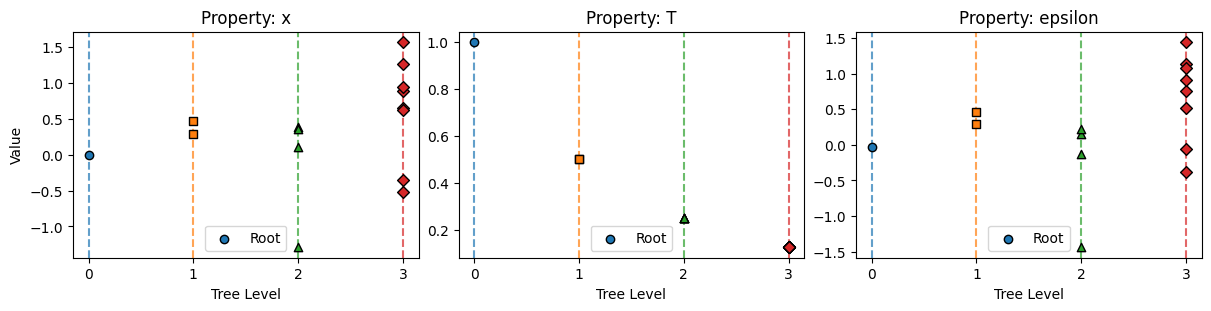

In [51]:
visualize_tree_properties(tree)

In [58]:
tree.add_property("x_hat", shape=())
tree.add_property("x_avg", shape=())
tree.add_property("inv_T", shape=())
leaf_x = tree.data['x'][tree.is_leaf]
tree.data['x_hat'] = tree.data['x_hat'].at[tree.is_leaf].set(leaf_x)

for k, v in tree.data.items():
    print(f"{k}: {v}, shape: {v.shape}\n")

x: [ 0.          0.46713185  0.29570296  0.38711184  0.10953311  0.36477464
 -1.2930275   0.89272463  0.65827435  0.94889617 -0.3457708   1.2687906
  1.5747535   0.62375236 -0.51344746], shape: (15,)

T: [1.    0.5   0.5   0.25  0.25  0.25  0.25  0.125 0.125 0.125 0.125 0.125
 0.125 0.125 0.125], shape: (15,)

epsilon: [-0.02830462  0.46713185  0.29570296  0.15354592 -0.12403282  0.21692315
 -1.440879    0.7558599   0.52140963  0.9101704  -0.3844966   1.1398233
  1.4457862   1.0809066  -0.05629321], shape: (15,)

x_hat: [ 0.          0.          0.          0.          0.          0.
  0.          0.89272463  0.65827435  0.94889617 -0.3457708   1.2687906
  1.5747535   0.62375236 -0.51344746], shape: (15,)

x_avg: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], shape: (15,)

inv_T: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.], shape: (15,)



In [59]:
@jax.jit
def up_fn(current_x_hat, current_T):
    return {
        'x_avg': current_x_hat / current_T,
        'inv_T': 1.0 / current_T
    }
    
@jax.jit
def transform_fn(current_x_avg, current_inv_T):
    return {
        'x_hat': current_x_avg / current_inv_T
    }

In [60]:
up_reduce_model = UpLambdaReducer(
    up_fn, transform_fn, 
    reductions={
        'x_avg': 'sum',
        'inv_T': 'sum'
    },
    up_preserves=[]
)
up_reduce_exe = OrderedExecutor(up_reduce_model)
up_reduce_exe.up(tree)

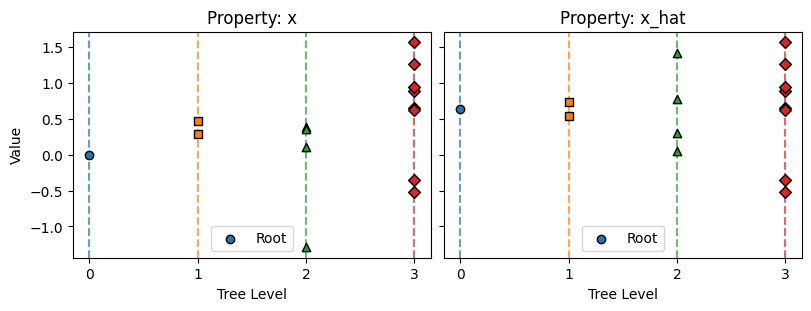

In [67]:
visualize_tree_properties(tree, property_names=("x", "x_hat"), sharey=True)

In [62]:
precomputed_tree = HypTree(topo, precompute_child_gathers=True)
precomputed_tree.data = tree.data.copy()

In [63]:
@jax.jit
def fast_up_fn(child_x_hat, child_T):
    inv_T = 1. / child_T
    norm = inv_T.sum(axis=1)
    current_x_hat = jnp.einsum('bc,bc->b', child_x_hat, inv_T) / norm
    return {
        'x_hat': current_x_hat
    } 

In [64]:
up_model = UpLambda(fast_up_fn)
up_exe = OrderedExecutor(up_model)
up_exe.up(precomputed_tree)

In [65]:
print((tree.data['x_hat'] == precomputed_tree.data['x_hat']).all())

True
